# Notebook 02. Exploratory Data Analysis for MoA Prediction

This notebook performs structured exploratory data analysis for the MoA Prediction project.

The goal is to understand the dataset patterns before feature engineering and model training.

This EDA will focus on:

- experimental metadata structure,
- scored and nonscored target behavior,
- multi-label target sparsity,
- gene expression feature patterns,
- cell viability feature patterns,
- train-test distribution consistency,
- target co-occurrence,
- representation structure using PCA,
- and feature engineering decisions.

This notebook will not train models.  
This notebook will not create final model-ready features.  
Those steps will be handled in later notebooks.

### Import libraries and define paths

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Interim data folder:", INTERIM_DATA_DIR)
print("Figure output folder:", FIGURE_DIR)

Project root: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response
Interim data folder: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response\data\interim
Figure output folder: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\moa-prediction-drug-response\outputs\figures


## 0.1 Load Clean Interim Data

In the previous notebook, we completed data integration and saved clean interim files.

In this EDA notebook, we will load those clean files directly from `data/interim/`.

We will not reload raw CSV files here because data validation and integration were already completed in Notebook 01.

In [2]:
train_features = pd.read_parquet(INTERIM_DATA_DIR / "train_features_clean.parquet")
test_features = pd.read_parquet(INTERIM_DATA_DIR / "test_features_clean.parquet")

y_scored = pd.read_parquet(INTERIM_DATA_DIR / "y_scored.parquet")
y_nonscored = pd.read_parquet(INTERIM_DATA_DIR / "y_nonscored.parquet")

train_drug = pd.read_parquet(INTERIM_DATA_DIR / "train_drug_clean.parquet")
train_main_scored = pd.read_parquet(INTERIM_DATA_DIR / "train_main_scored.parquet")
train_with_drug = pd.read_parquet(INTERIM_DATA_DIR / "train_with_drug.parquet")

with open(INTERIM_DATA_DIR / "feature_groups.json", "r") as f:
    feature_groups = json.load(f)

print("Clean interim data loaded successfully.")

Clean interim data loaded successfully.


## 0.2 EDA Asset Overview

Before starting analysis, we check the shapes of the clean files loaded for EDA.

This confirms that the EDA notebook is using the correct outputs from the data integration notebook.

In [3]:
eda_asset_overview = pd.DataFrame({
    "asset_name": [
        "train_features",
        "test_features",
        "y_scored",
        "y_nonscored",
        "train_drug",
        "train_main_scored",
        "train_with_drug",
    ],
    "rows": [
        train_features.shape[0],
        test_features.shape[0],
        y_scored.shape[0],
        y_nonscored.shape[0],
        train_drug.shape[0],
        train_main_scored.shape[0],
        train_with_drug.shape[0],
    ],
    "columns": [
        train_features.shape[1],
        test_features.shape[1],
        y_scored.shape[1],
        y_nonscored.shape[1],
        train_drug.shape[1],
        train_main_scored.shape[1],
        train_with_drug.shape[1],
    ],
})

eda_asset_overview

,asset_name,rows,columns
0,train_features,23814,876
1,test_features,3982,876
2,y_scored,23814,207
3,y_nonscored,23814,403
4,train_drug,23814,2
5,train_main_scored,23814,1082
6,train_with_drug,23814,877


## 0.3 Load Feature Groups

The previous notebook saved the feature groups in `feature_groups.json`.

We load those groups here so that every analysis uses the same column definitions.

In [4]:
ID_COL = feature_groups["id_col"]

metadata_features = feature_groups["metadata_features"]
gene_features = feature_groups["gene_features"]
cell_features = feature_groups["cell_features"]

scored_target_features = feature_groups["scored_target_features"]
nonscored_target_features = feature_groups["nonscored_target_features"]

feature_group_check = pd.DataFrame({
    "group": [
        "ID column",
        "metadata features",
        "gene features",
        "cell features",
        "scored targets",
        "nonscored targets",
    ],
    "count": [
        1,
        len(metadata_features),
        len(gene_features),
        len(cell_features),
        len(scored_target_features),
        len(nonscored_target_features),
    ]
})

feature_group_check

,group,count
0,ID column,1
1,metadata features,3
2,gene features,772
3,cell features,100
4,scored targets,206
5,nonscored targets,402


## 2. Experimental Design and Metadata Audit

The MoA dataset contains three important metadata columns:

- `cp_type`: treatment type
- `cp_time`: treatment duration
- `cp_dose`: treatment dose

These columns describe the experimental condition for each biological sample.

Before analyzing targets or biological features, we first check whether the experimental setup is balanced and whether train and test metadata distributions are similar.

This section helps us decide:

- how metadata should be encoded later,
- whether train and test have distribution shift,
- whether control samples need special treatment,
- and whether metadata interaction features may be useful.

### 2.1 Metadata Cardinality Check

First, we check the number of unique values in each metadata column for both train and test data.

This confirms whether the metadata columns contain the expected categories and whether train/test categories match.

In [5]:
metadata_cardinality_report = []

for col in metadata_features:
    train_unique = sorted(train_features[col].unique().tolist())
    test_unique = sorted(test_features[col].unique().tolist())
    
    metadata_cardinality_report.append({
        "column": col,
        "train_unique_count": train_features[col].nunique(),
        "test_unique_count": test_features[col].nunique(),
        "train_unique_values": train_unique,
        "test_unique_values": test_unique,
        "same_categories": set(train_unique) == set(test_unique),
    })

metadata_cardinality_report = pd.DataFrame(metadata_cardinality_report)
metadata_cardinality_report

,column,train_unique_count,test_unique_count,train_unique_values,test_unique_values,same_categories
0,cp_type,2,2,"[ctl_vehicle, trt_cp]","[ctl_vehicle, trt_cp]",True
1,cp_time,3,3,"[24, 48, 72]","[24, 48, 72]",True
2,cp_dose,2,2,"[D1, D2]","[D1, D2]",True


### 2.2 Train vs Test Metadata Distribution

Next, we compare the percentage distribution of metadata categories between train and test data.

Counts alone can be misleading because train and test have different row counts.  
So we compare percentages instead of only raw counts.

In [8]:
def metadata_distribution_table(train_df, test_df, column):
    train_dist = (
        train_df[column]
        .value_counts(normalize=True)
        .mul(100)
        .rename("train_percent")
        .rename_axis("category")
        .reset_index()
    )
    
    test_dist = (
        test_df[column]
        .value_counts(normalize=True)
        .mul(100)
        .rename("test_percent")
        .rename_axis("category")
        .reset_index()
    )
    
    table = train_dist.merge(
        test_dist,
        on="category",
        how="outer"
    ).fillna(0)
    
    table["percent_difference"] = table["test_percent"] - table["train_percent"]
    table.insert(0, "metadata_column", column)
    
    return table


metadata_distribution_tables = []

for col in metadata_features:
    metadata_distribution_tables.append(
        metadata_distribution_table(train_features, test_features, col)
    )

metadata_distribution_comparison = pd.concat(
    metadata_distribution_tables,
    axis=0,
    ignore_index=True
)

metadata_distribution_comparison

,metadata_column,category,train_percent,test_percent,percent_difference
0,cp_type,ctl_vehicle,7.835727,8.990457,1.154730
1,cp_type,trt_cp,92.164273,91.009543,-1.154730
2,cp_time,24,32.636264,32.646911,0.010647
3,cp_time,48,34.643487,34.580613,-0.062874
4,cp_time,72,32.720249,32.772476,0.052228
5,cp_dose,D1,51.007811,50.904068,-0.103742
6,cp_dose,D2,48.992189,49.095932,0.103742


### 2.3 Visualize Train vs Test Metadata Distribution

Now we visualize train and test metadata distributions using percentage bar plots.

The purpose is to quickly see whether train and test have similar experimental setups.

These plots are more useful than raw count plots because train and test have different numbers of rows.

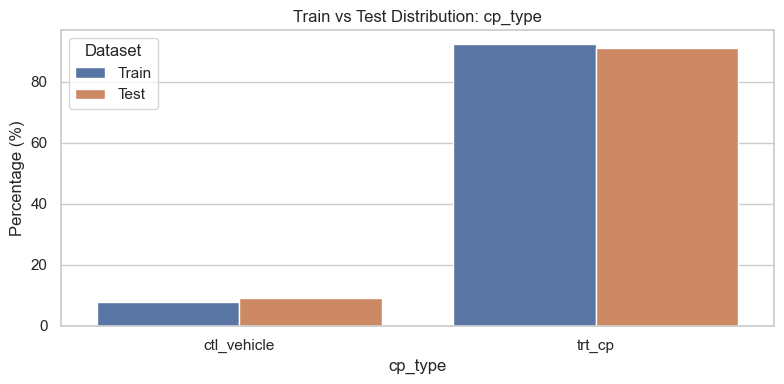

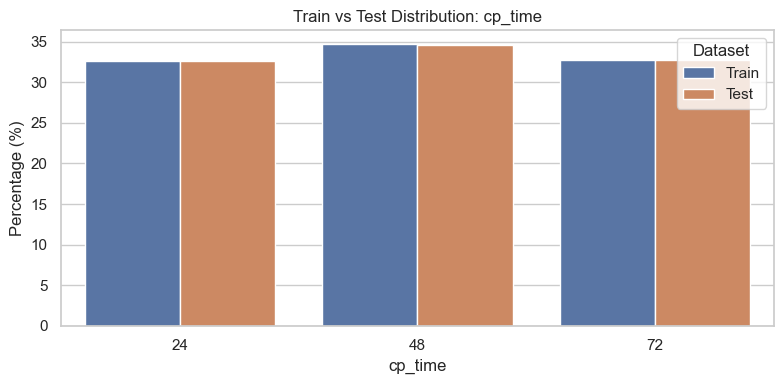

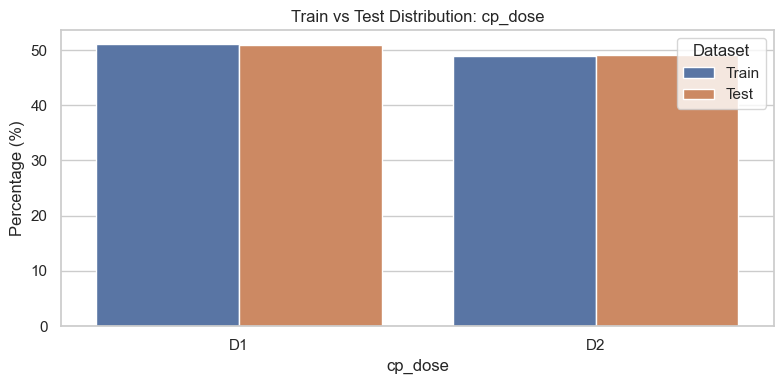

In [9]:
def plot_train_test_metadata_distribution(comparison_df, column):
    plot_df = comparison_df[comparison_df["metadata_column"] == column].copy()
    
    plot_df_long = plot_df.melt(
        id_vars=["category"],
        value_vars=["train_percent", "test_percent"],
        var_name="dataset",
        value_name="percentage"
    )
    
    plot_df_long["dataset"] = plot_df_long["dataset"].replace({
        "train_percent": "Train",
        "test_percent": "Test"
    })
    
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=plot_df_long,
        x="category",
        y="percentage",
        hue="dataset"
    )
    
    plt.title(f"Train vs Test Distribution: {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage (%)")
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()


for col in metadata_features:
    plot_train_test_metadata_distribution(metadata_distribution_comparison, col)

### 2.4 Metadata Analysis: Initial Insights

The metadata distribution comparison shows that train and test have very similar experimental setups.

The `cp_time` and `cp_dose` distributions are almost identical between train and test.  
The `cp_type` distribution has a small difference: test data contains slightly more control samples and slightly fewer treated samples compared with train data.

This difference is small and does not indicate a serious metadata shift.

Key decisions from this section:

- `cp_type`, `cp_time`, and `cp_dose` should be kept as important metadata features.
- These metadata columns should be encoded during feature engineering.
- `ctl_vehicle` control samples should be handled carefully because they have no active MoA targets.
- Interaction features such as `cp_time × cp_dose` may be useful and should be explored next.

### 2.5 Metadata Interaction Analysis

Now we analyze combinations of metadata features.

Single metadata columns looked balanced, but we also need to check whether combinations such as `cp_time × cp_dose` are balanced.

This helps us understand the experimental design more clearly and decide whether interaction features may be useful later.

In [10]:
metadata_interaction_pairs = [
    ("cp_time", "cp_dose"),
    ("cp_type", "cp_time"),
    ("cp_type", "cp_dose"),
]

interaction_tables = {}

for col1, col2 in metadata_interaction_pairs:
    interaction_name = f"{col1}_x_{col2}"
    
    interaction_table = (
        train_features
        .groupby([col1, col2])
        .size()
        .reset_index(name="train_count")
    )
    
    interaction_table["train_percent"] = (
        interaction_table["train_count"] / len(train_features) * 100
    )
    
    interaction_tables[interaction_name] = interaction_table
    
    print(f"\n{interaction_name}")
    display(interaction_table)


cp_time_x_cp_dose


,cp_time,cp_dose,train_count,train_percent
0,24,D1,3886,16.318132
1,24,D2,3886,16.318132
2,48,D1,4354,18.283363
3,48,D2,3896,16.360124
4,72,D1,3907,16.406316
5,72,D2,3885,16.313933



cp_type_x_cp_time


,cp_type,cp_time,train_count,train_percent
0,ctl_vehicle,24,606,2.544722
1,ctl_vehicle,48,648,2.721088
2,ctl_vehicle,72,612,2.569917
3,trt_cp,24,7166,30.091543
4,trt_cp,48,7602,31.922399
5,trt_cp,72,7180,30.150332



cp_type_x_cp_dose


,cp_type,cp_dose,train_count,train_percent
0,ctl_vehicle,D1,951,3.993449
1,ctl_vehicle,D2,915,3.842278
2,trt_cp,D1,11196,47.014361
3,trt_cp,D2,10752,45.149912


### 2.5.1 Train vs Test Metadata Interaction Comparison

Now we compare metadata interaction percentages between train and test.

This helps us check whether train and test have similar experimental combinations, not only similar individual metadata columns.

In [11]:
def interaction_distribution_table(train_df, test_df, col1, col2):
    train_dist = (
        train_df
        .groupby([col1, col2])
        .size()
        .reset_index(name="train_count")
    )
    train_dist["train_percent"] = train_dist["train_count"] / len(train_df) * 100

    test_dist = (
        test_df
        .groupby([col1, col2])
        .size()
        .reset_index(name="test_count")
    )
    test_dist["test_percent"] = test_dist["test_count"] / len(test_df) * 100

    table = train_dist.merge(
        test_dist,
        on=[col1, col2],
        how="outer"
    ).fillna(0)

    table["percent_difference"] = table["test_percent"] - table["train_percent"]
    table.insert(0, "interaction", f"{col1}_x_{col2}")

    return table


interaction_comparison_tables = []

for col1, col2 in metadata_interaction_pairs:
    interaction_comparison_tables.append(
        interaction_distribution_table(train_features, test_features, col1, col2)
    )

metadata_interaction_comparison = pd.concat(
    interaction_comparison_tables,
    axis=0,
    ignore_index=True
)

metadata_interaction_comparison

,interaction,cp_time,cp_dose,train_count,train_percent,test_count,test_percent,percent_difference,cp_type
0,cp_time_x_cp_dose,24.0,D1,3886,16.318132,648,16.273230,-0.044903,NaN
1,cp_time_x_cp_dose,24.0,D2,3886,16.318132,652,16.373682,0.055549,NaN
2,cp_time_x_cp_dose,48.0,D1,4354,18.283363,725,18.206931,-0.076432,NaN
3,cp_time_x_cp_dose,48.0,D2,3896,16.360124,652,16.373682,0.013557,NaN
4,cp_time_x_cp_dose,72.0,D1,3907,16.406316,654,16.423908,0.017592,NaN
5,cp_time_x_cp_dose,72.0,D2,3885,16.313933,651,16.348569,0.034636,NaN
6,cp_type_x_cp_time,24.0,NaN,606,2.544722,116,2.913109,0.368387,ctl_vehicle
7,cp_type_x_cp_time,48.0,NaN,648,2.721088,124,3.114013,0.392925,ctl_vehicle
8,cp_type_x_cp_time,72.0,NaN,612,2.569917,118,2.963335,0.393418,ctl_vehicle
9,cp_type_x_cp_time,24.0,NaN,7166,30.091543,1184,29.733802,-0.357741,trt_cp


### 2.5.2 Visualize Time-Dose Experimental Balance

The `cp_time × cp_dose` interaction is especially important because treatment time and dose may jointly affect biological response.

We visualize this interaction using heatmaps for train and test data.

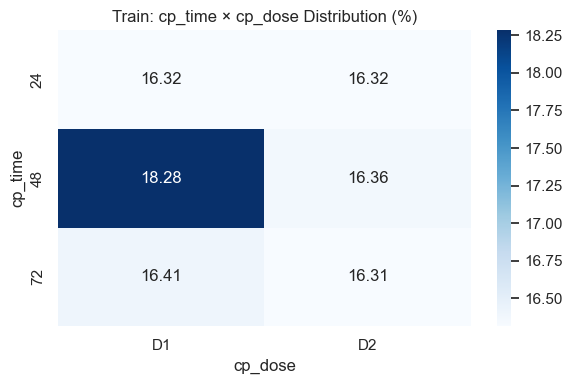

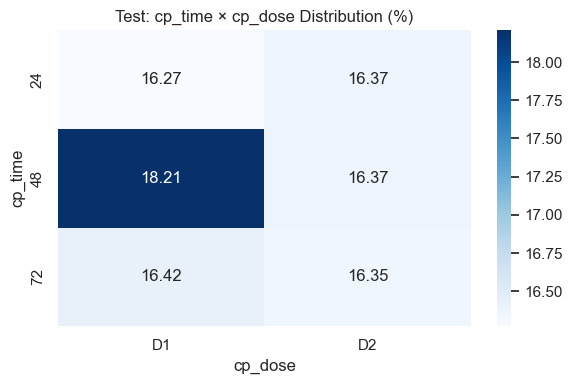

In [12]:
def plot_time_dose_heatmap(df, title):
    heatmap_data = (
        df
        .groupby(["cp_time", "cp_dose"])
        .size()
        .reset_index(name="count")
    )
    
    heatmap_data["percent"] = heatmap_data["count"] / len(df) * 100
    
    heatmap_pivot = heatmap_data.pivot(
        index="cp_time",
        columns="cp_dose",
        values="percent"
    )
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt=".2f",
        cmap="Blues"
    )
    plt.title(title)
    plt.xlabel("cp_dose")
    plt.ylabel("cp_time")
    plt.tight_layout()
    plt.show()


plot_time_dose_heatmap(train_features, "Train: cp_time × cp_dose Distribution (%)")
plot_time_dose_heatmap(test_features, "Test: cp_time × cp_dose Distribution (%)")

### 2.6 Metadata Interaction Insights and Decisions

The metadata interaction analysis shows that the experimental design is mostly balanced between train and test.

The `cp_time × cp_dose` heatmaps are especially useful because treatment duration and dose may jointly affect biological response. Both train and test show very similar time-dose patterns. The `48 × D1` group is slightly larger than the other time-dose combinations, but this pattern appears in both train and test, so it does not indicate a serious train-test shift.

The `cp_type × cp_time` and `cp_type × cp_dose` combinations also show the expected structure. Control samples are a small portion of the dataset and are distributed across time and dose conditions. Test data has slightly more control samples than train data, but the difference is small.

Main conclusions:

- Metadata combinations are consistent between train and test.
- There is no strong experimental-design distribution shift.
- `cp_time × cp_dose` may be useful as an interaction feature.
- `cp_type` should be kept because it separates treated and control samples.
- Control samples should be handled carefully during final prediction because they have no active MoA targets.